In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
%load_ext autoreload
%autoreload 2

from cdk.analysis.cytosol import platereader as pr
import warnings

# Ignore warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Analysis: 20250811

All the data is in the same file, so I just updated the platemap to include everything and to add some extra labels we can slice the data by and to make the names simpler so that the legends are easier to interpret. The original spreadsheet is [here on google drive](https://docs.google.com/spreadsheets/d/1UHafCZ0OuN6uwy3IjGm4Jo9WtTPgtQsRLf3Ll2aYKBg/edit?usp=sharing).

In [3]:
platemap_path = "../Platemap (acjs)/20250811-acjs-PPK-platemap.tsv"
data_path = "../data/20250729-104410-cytation5-pure-timecourse-gfp--biotek-cdk.txt"

data, platemap = pr.load_platereader_data(data_path, platemap_path)

# Plots

Make some timeseries plots. We can add extra parameters to slice the data different ways (like `hue` and `col` below). The `plot_curves` function takes the same parameters as [relplot in Seaborn](https://seaborn.pydata.org/generated/seaborn.relplot.html).

Make a plot per crowding molecule (`col="Crowder"`), coloring each line by the kind of metabolism (`hue="Metabolism"`).

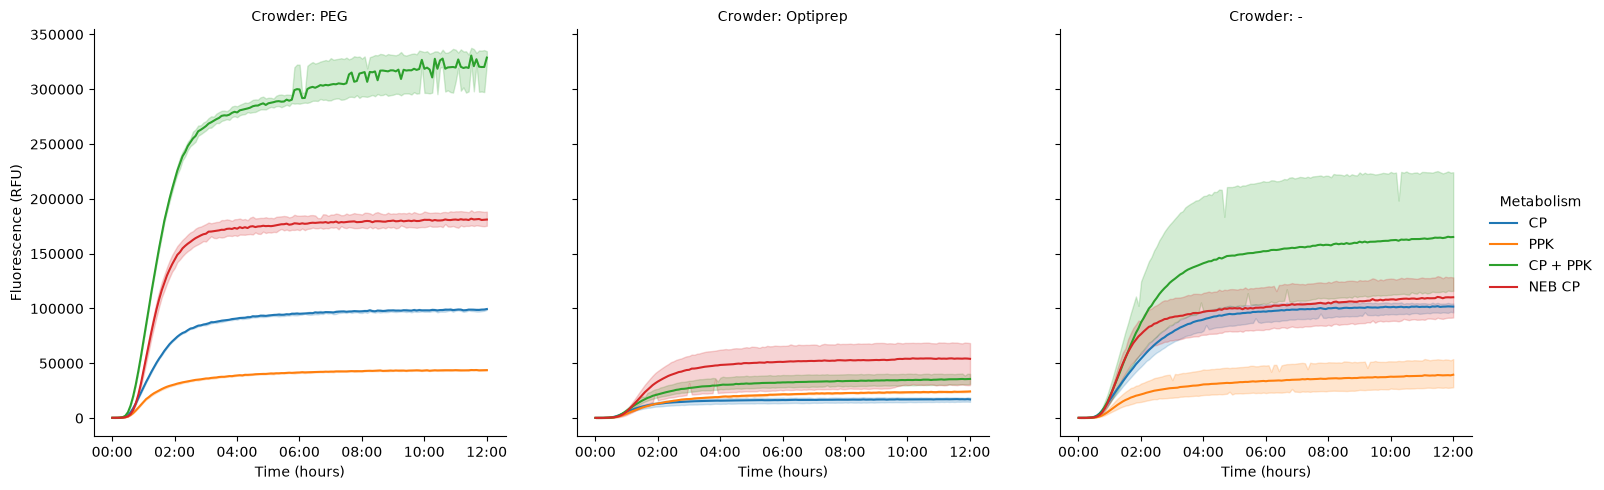

In [4]:
pr.plot_curves(data, hue="Metabolism", col="Crowder");

Swap them around, so we're looking at the difference between crowders, split out by the kind of metabolism. It's interesting that CP is really similar for both PEG and no crowder, while PEG solidly beats no crowder in the NEB positive.

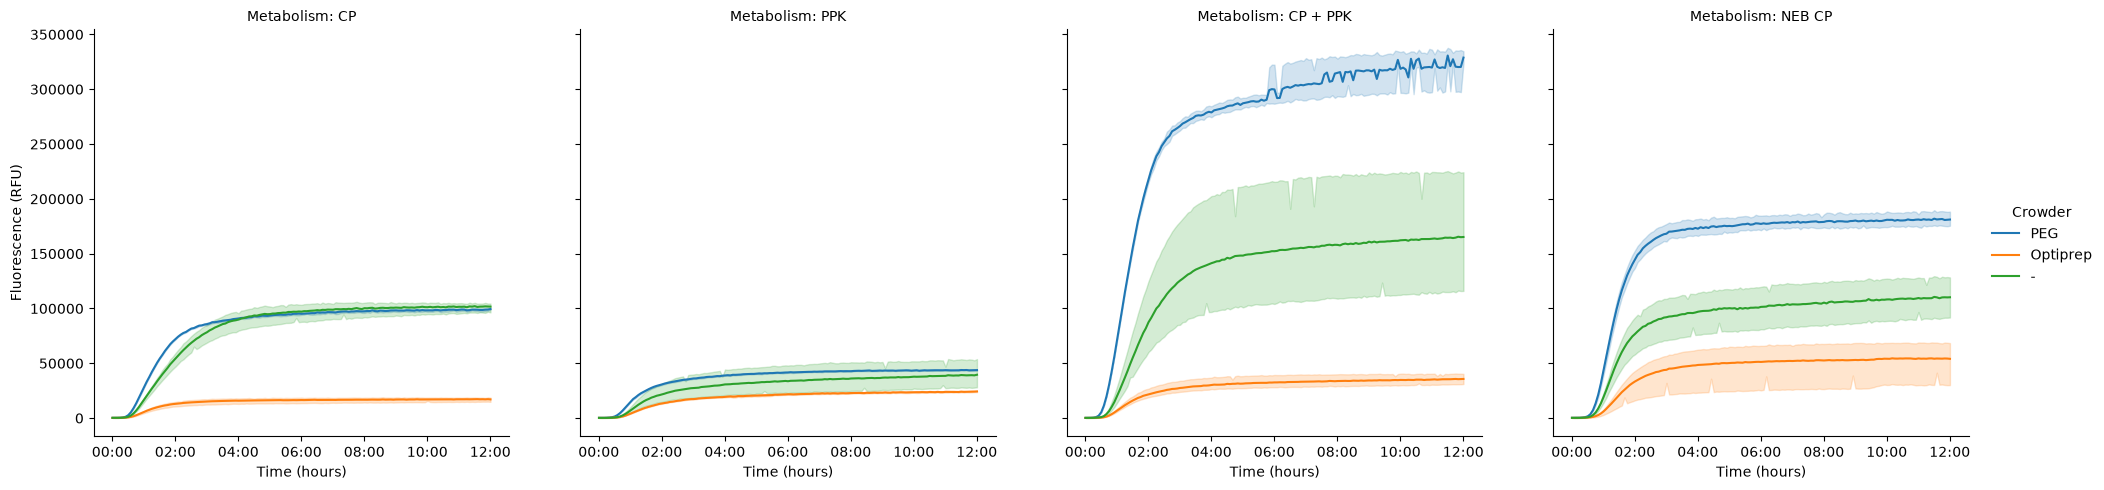

In [5]:
pr.plot_curves(data, hue="Crowder", col="Metabolism");

## Replicates

Let's take a look at the individual traces, to see where the wide errors on the traces are coming from.

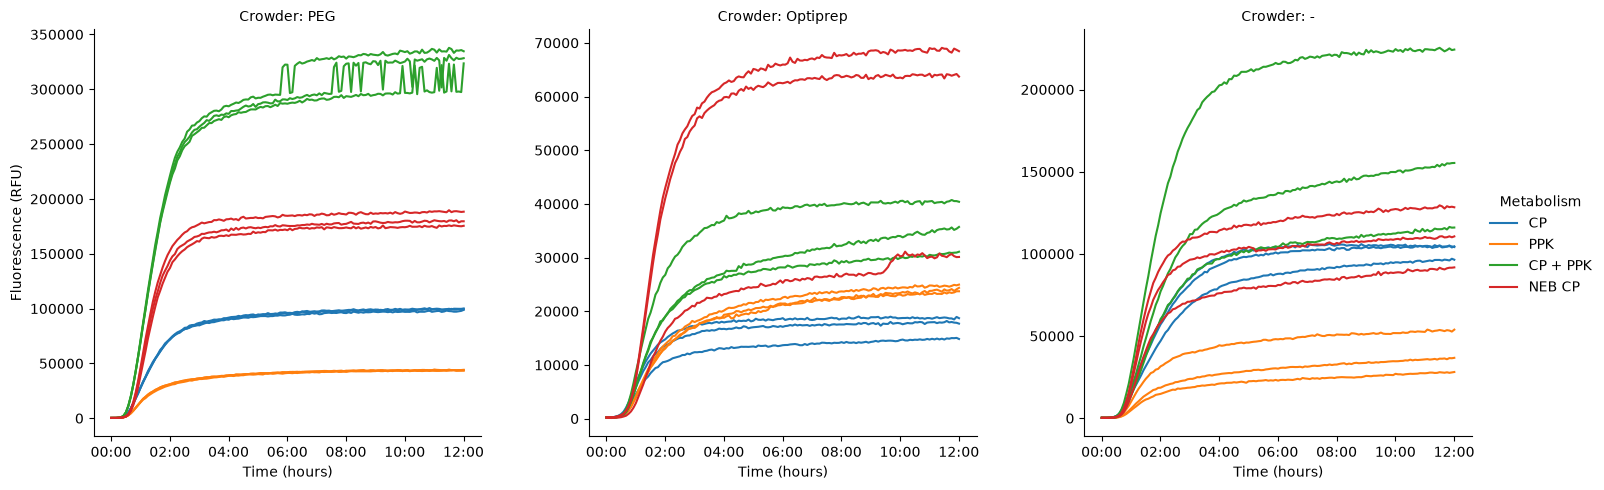

In [6]:
pr.plot_curves(data, hue="Metabolism", col="Crowder", units="Well", estimator=None, facet_kws={"sharey":False});

Looks like the variance is, in general, coming from either a very high or very low replicate within a set. In the Optiprep set, we see two nice high lines for the NEB positive, plus one weirdly low one. In the no-crowder set, we see a nice high curve for CP+PPK, and two lower curves, though they're all kind of spread out. The three NEB positive lines are also spread out, though not so much. 

The PEG lines are all nicely clustered, and we see the weird step change happen to all of them (at different times). Unclear what this is--worth digging into. Given the wells were in different parts of the plate, it's also interesting to consider whether the higher variance is somehow coming from their location on plate.

Let's plot them with a shared Y axis, just to see the variance, etc, in relation to the overall scale of the experiment as a whole.

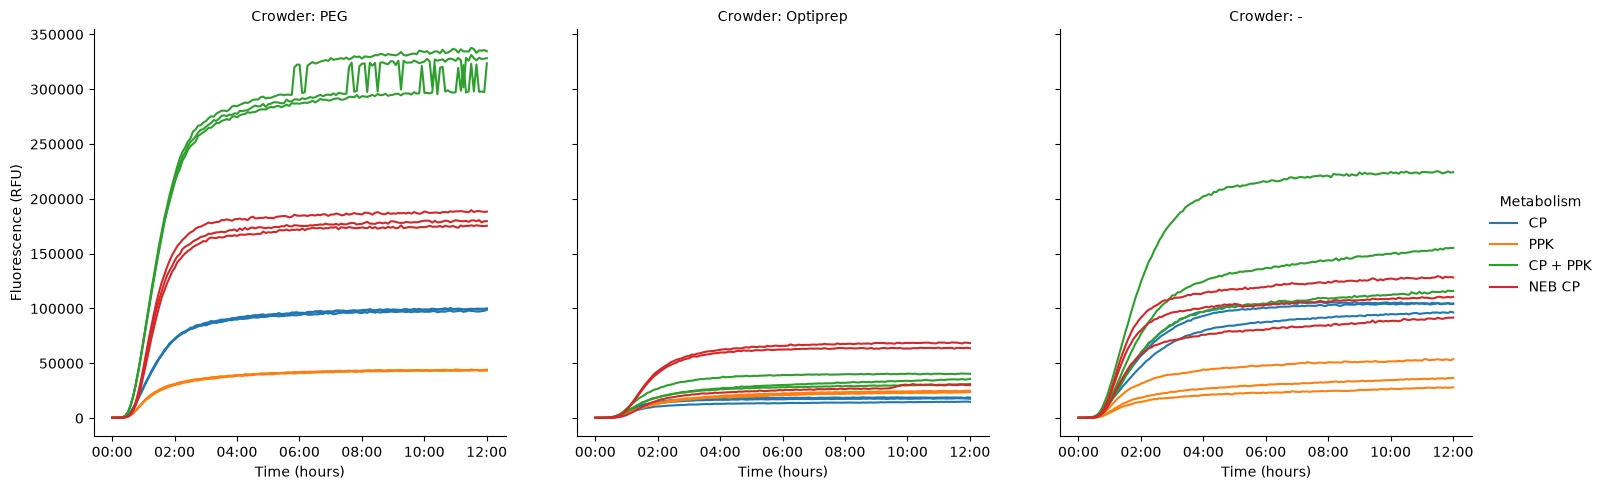

In [7]:
pr.plot_curves(data, hue="Metabolism", col="Crowder", units="Well", estimator=None);

We can also crop back the time to ~steady state, so that we can better see differences in the early kinetic curve.

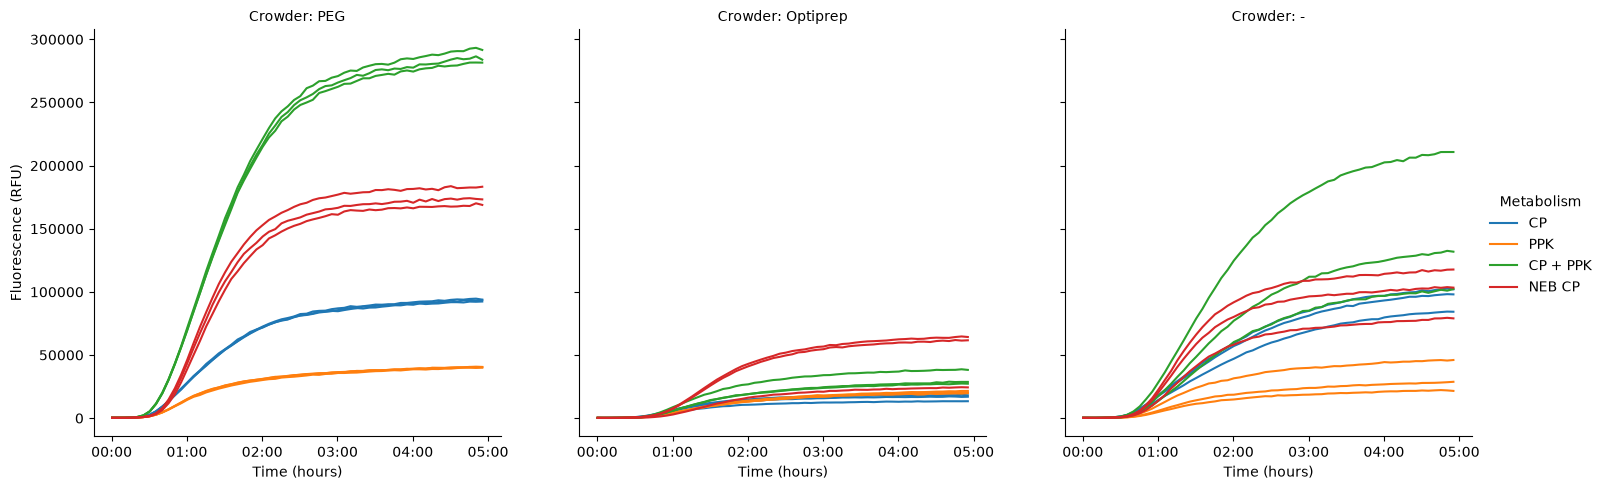

In [8]:
pr.plot_curves(data[data["Time"] < "5:00:00"], hue="Metabolism", col="Crowder", units="Well", estimator=None);

To really split it out, we could look at only the replicates for each Crowder-Metabolism pair, so we're just looking at three lines per plot.

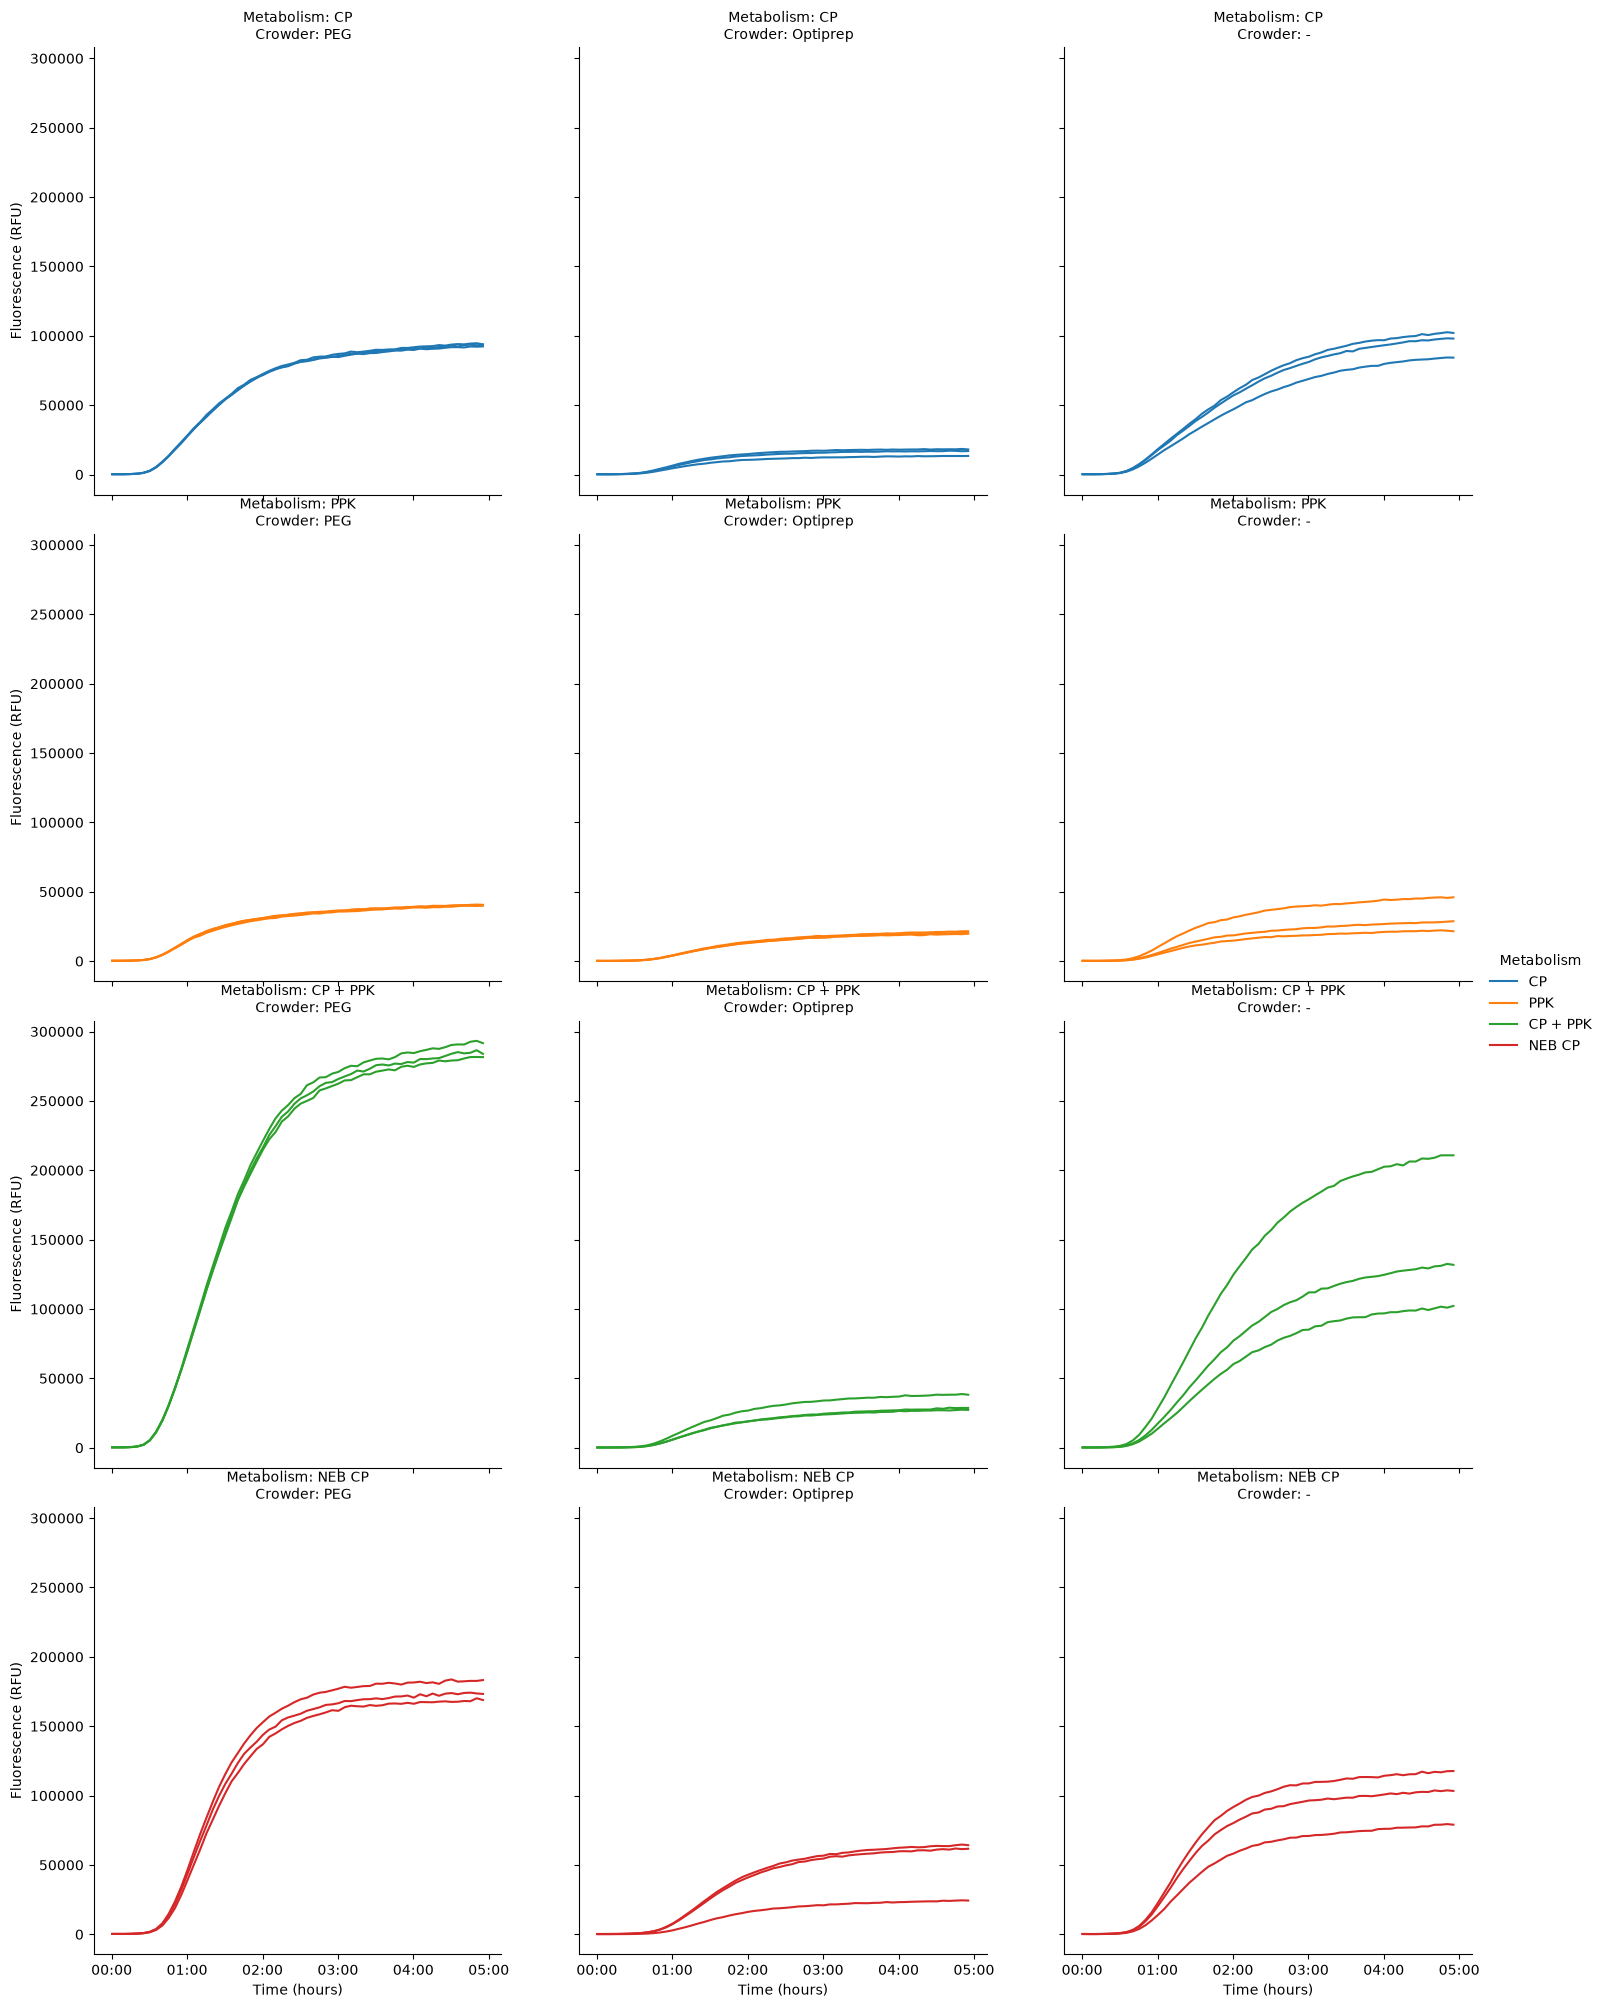

In [9]:
pr.plot_curves(data[data["Time"] < "5:00:00"], hue="Metabolism", row="Metabolism", col="Crowder", units="Well", estimator=None);

## Steady state

Same as we did for the timeseries, this time doing the kind of metabolism on the x axis (`x="Metabolism"`) and crowder as color (`hue="Crowder"`).

In [10]:
# pr.plot_steadystate(data, x="Metabolism", hue="Crowder") - broken in installed nucleus-cdk: hue referencing a column other than x fails (the merge that restores full platemap columns was commented out upstream). Filed as https://github.com/bnext-bio/bnext/issues/67.

Swap them around like we did before, in case this is easier to read.

In [11]:
# pr.plot_steadystate(data, x="Crowder", hue="Metabolism") - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

Make a plot like we had above, with one panel per crowder.

In [12]:
# pr.plot_steadystate(data, x="Metabolism", hue="Metabolism", col="Crowder", col_wrap=3) - broken in installed nucleus-cdk (col != x), see https://github.com/bnext-bio/bnext/issues/67

## Error Bars

The error bars are noticeably smaller than what we'd guess by eye from the curves--why is this? By default, the error bars are plotting the 95% confidence interval--the range within which we expect the true mean falls. There are other ways to visualize the error. First, let's look at what all the steady states look like (per well):

In [13]:
# pr.plot_steadystate(data, x="Well", hue="Metabolism", col="Crowder", col_wrap=3) - broken in installed nucleus-cdk (x="Well" duplicates the Well column internally), see https://github.com/bnext-bio/bnext/issues/67

This matches what we see in the curves more closely. The variance in some of the experiments looks a lot less bad, when scaled to the max of the best experiment (this might actually be kind of misleading though).

Let's plot one of the earlier graphs, but with some different estimates of error/variance. Check out [the seaborn documentation on uncertainty](https://seaborn.pydata.org/tutorial/error_bars.html) for an explanation of what these all are.

First, standard deviation:

In [14]:
# pr.plot_steadystate(data, x="Crowder", hue="Metabolism", errorbar="sd") - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

This looks a lot more like we're expecting. What about percent interval?

In [15]:
# pr.plot_steadystate(data, x="Crowder", hue="Metabolism", errorbar="pi") - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

Also pretty solid. We can try the standard error:

In [16]:
# pr.plot_steadystate(data, x="Crowder", hue="Metabolism", errorbar="se") - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

This is unsurprisingly similar to the 95% confidence interval, given our low number of samples. Overall, we should probably change the default errorbar estimator to the standard deviation, since it's less surprising and we're unlikely to have a large population in any sample (large number of replicates).

We can also provide a custom estimator--let's use one that plots the range:

In [17]:
# pr.plot_steadystate(data, x="Crowder", hue="Metabolism", errorbar=lambda x: (x.min(), x.max())) - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

Perhaps this is even better than the SD, since we know we're likely to have 2-3, and probably at most 5, replicates of a given sample. 

New feature inspired--let's plot the raw data points (per well) on top of the bars:

In [18]:
# pr.plot_steadystate(data, x="Crowder", hue="Metabolism", show_points=True) - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

# Mg Concentration vs Optiprep

In [19]:
# pr.plot_steadystate(data, x="Crowder", hue="[Mg2+]", show_points=True) - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

In [20]:
# pr.plot_steadystate(data, hue="[Mg2+]", col="Crowder", x="Type", sharey=False, show_points=True) - broken in installed nucleus-cdk, see https://github.com/bnext-bio/bnext/issues/67

# Kinetics Analysis

Plot the overall kinetics. This plot is going to be huge, so we increase the number of columns we're willing to make (`col_wrap=4`).

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x15b25bc50>,
                                                Velocity                      \
                                                    Time      Data       Max   
 Name                 Read                                                     
 CP                   GFP-Gext 0 days 01:56:49.703175980  51591.90  35360.10   
 CP (+Optiprep)       GFP-Gext 0 days 01:09:25.838032851   8458.97   9526.62   
 CP (+PEG)            GFP-Gext 0 days 01:20:01.629748317  50166.86  48561.41   
 CP + PPK             GFP-Gext 0 days 02:08:00.636863372  82809.95  56270.27   
 CP + PPK (+Optiprep) GFP-Gext 0 days 01:39:44.298348783  17539.25  12935.71   
 CP + PPK (+PEG)      GFP-Gext 0 days 01:35:50.167726917 157886.49 137146.38   
 NEB PURE             GFP-Gext 0 days 01:36:21.250299620  52613.59  56607.93   
 NEB PURE (+Optiprep) GFP-Gext 0 days 01:35:28.257610413  25175.82  25756.01   
 NEB PURE (+PEG)      GFP-Gext 0 days 01:21:08.673754170  90442.83 123669.

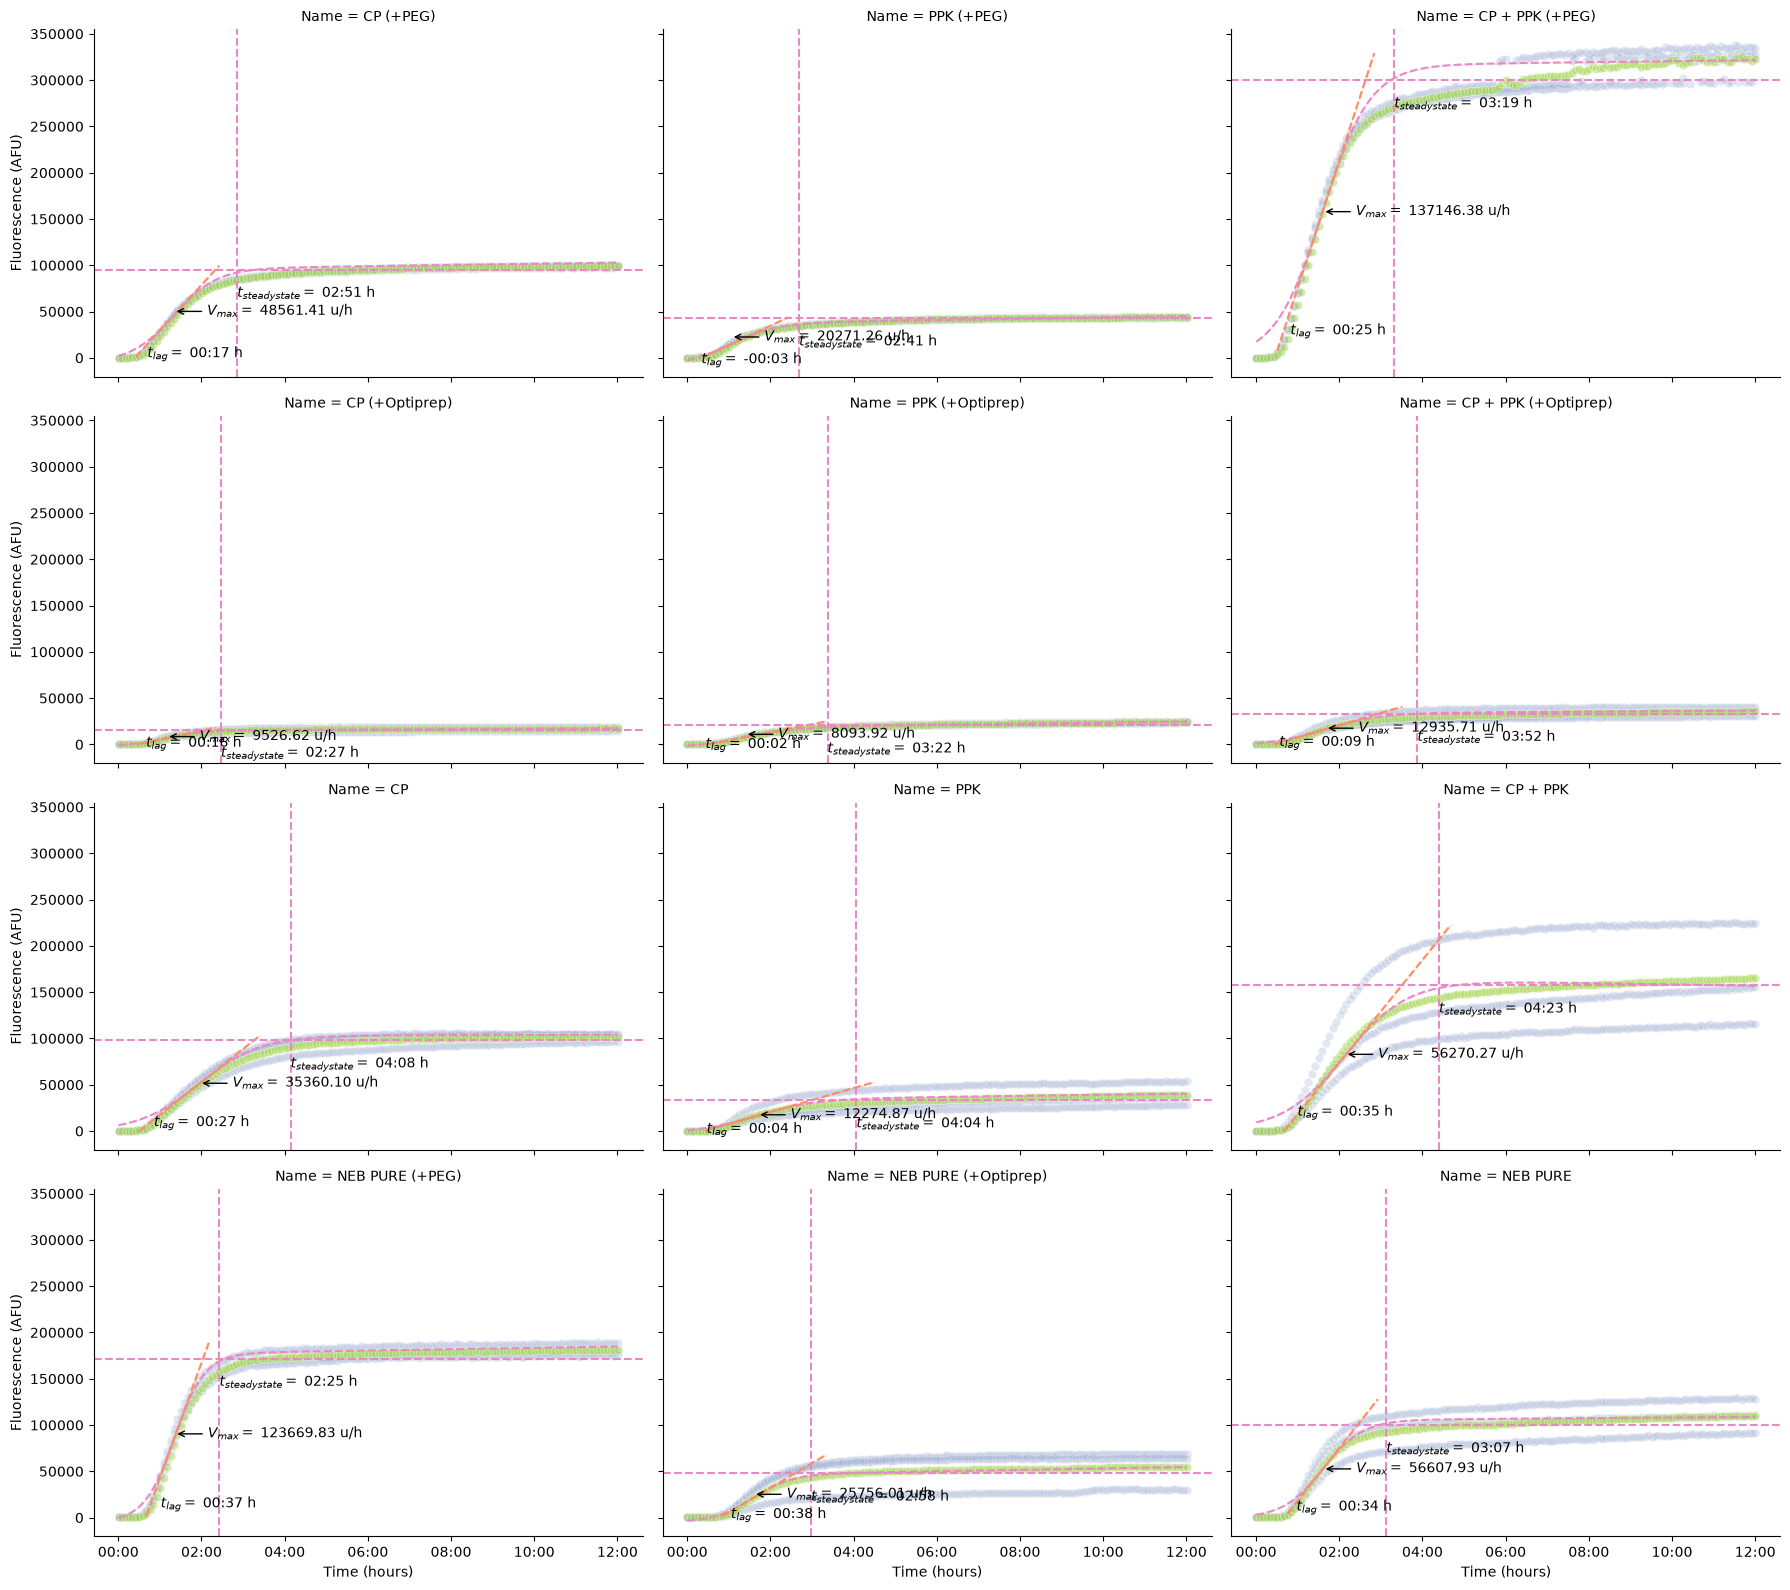

In [21]:
pr.plot_kinetics(data, col_wrap=3)

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x159571310>,
                                                Velocity                      \
                                                    Time      Data       Max   
 Name                 Read                                                     
 CP                   GFP-Gext 0 days 01:56:49.703175980  51591.90  35360.10   
 CP (+Optiprep)       GFP-Gext 0 days 01:09:25.838032851   8458.97   9526.62   
 CP (+PEG)            GFP-Gext 0 days 01:20:01.629748317  50166.86  48561.41   
 CP + PPK             GFP-Gext 0 days 02:08:00.636863372  82809.95  56270.27   
 CP + PPK (+Optiprep) GFP-Gext 0 days 01:39:44.298348783  17539.25  12935.71   
 CP + PPK (+PEG)      GFP-Gext 0 days 01:35:50.167726917 157886.49 137146.38   
 NEB PURE             GFP-Gext 0 days 01:36:21.250299620  52613.59  56607.93   
 NEB PURE (+Optiprep) GFP-Gext 0 days 01:35:28.257610413  25175.82  25756.01   
 NEB PURE (+PEG)      GFP-Gext 0 days 01:21:08.673754170  90442.83 123669.

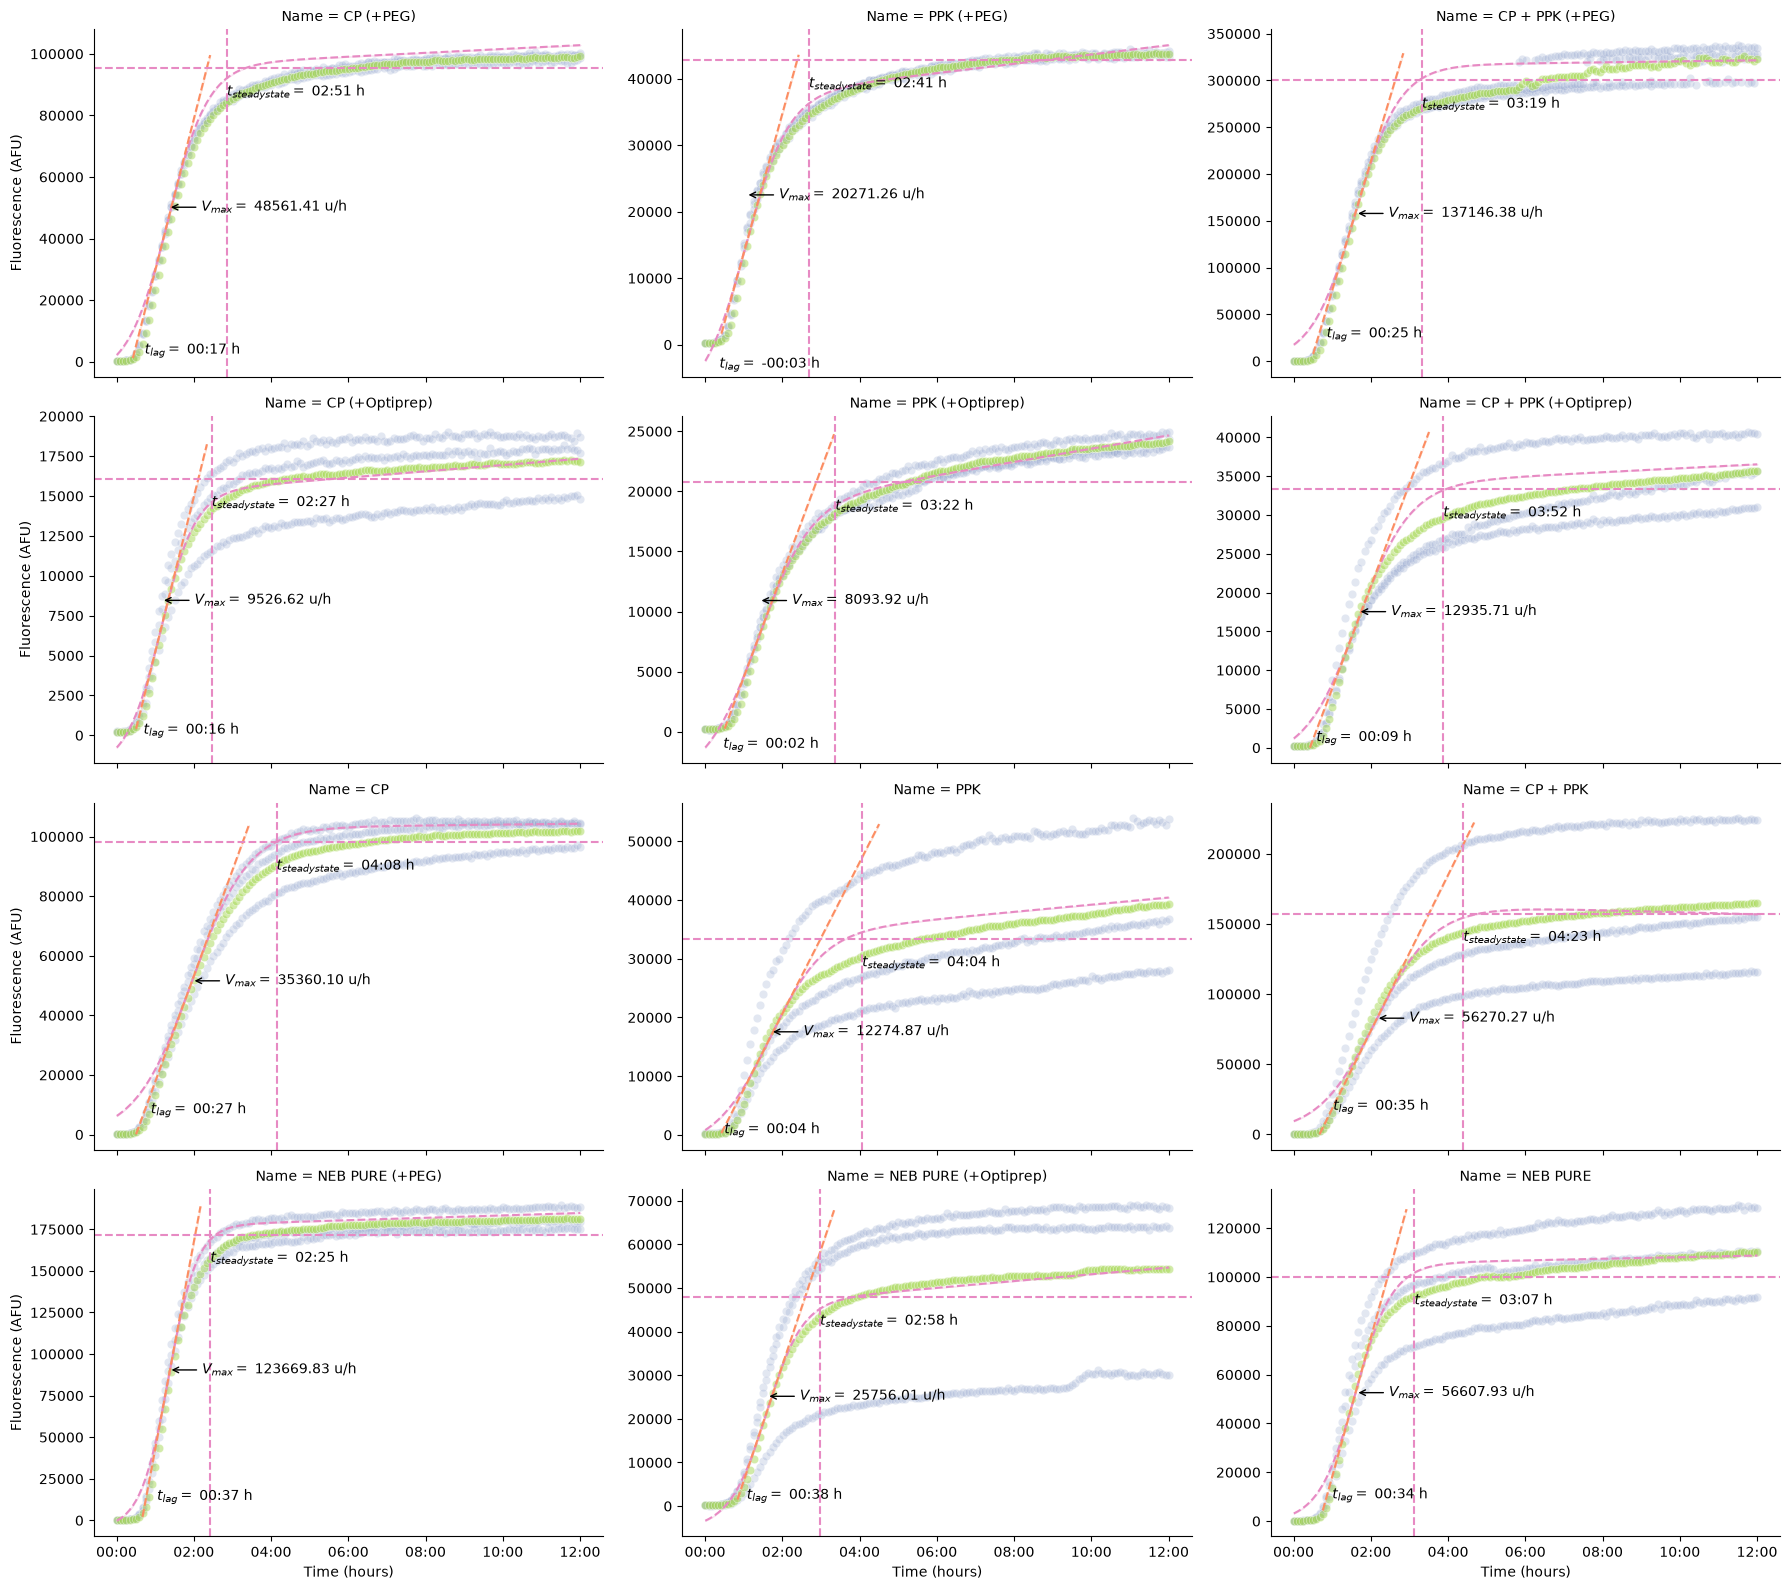

In [22]:
pr.plot_kinetics(data, col_wrap=3, sharey=False)

We don't have specific functions yet, but we can also use the kinetic analysis table to drill into some specifics (like how long each well takes to get to steady state).

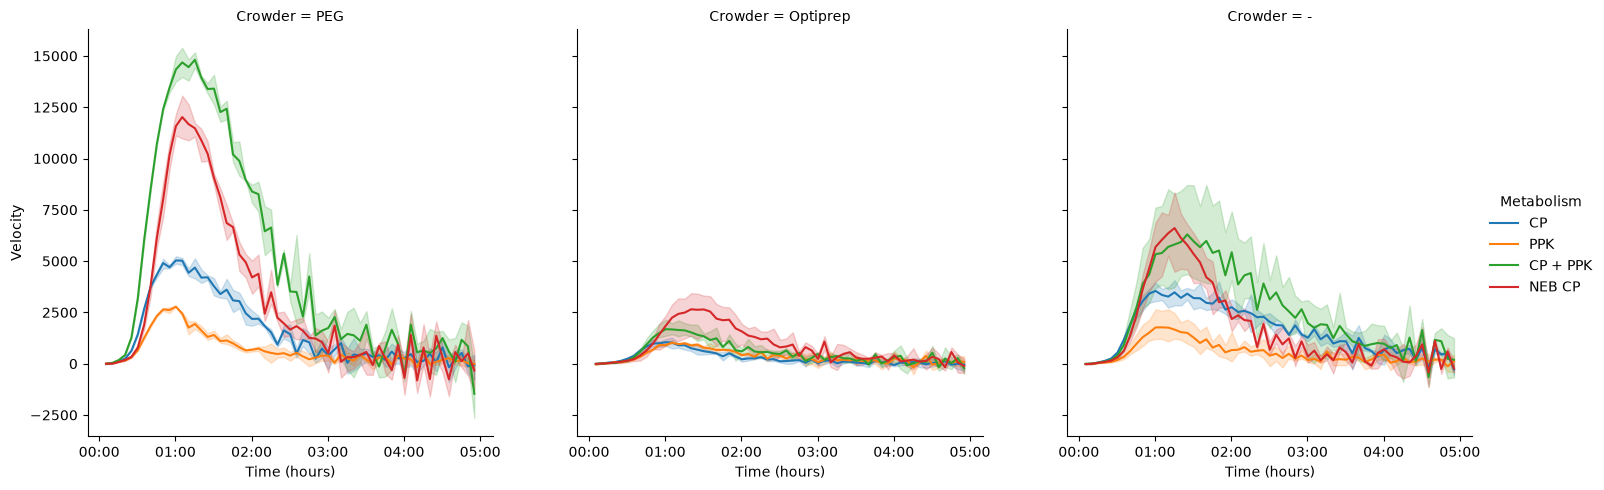

In [23]:
import seaborn as sns

data["Velocity"] = data["Data"].diff()
g = sns.relplot(
    data=data[(data["Time"] > "00:00:30") & (data["Time"] <= "5:00:00")], 
    x="Time", 
    y="Velocity", 
    hue="Metabolism", 
    col="Crowder", 
    kind="line")
pr._plot_timedelta(g)

In [24]:
kinetics = pr.kinetic_analysis(data)
kinetics

Velocity            \
                                                        Time      Data   
Name                 Read     Well                                       
CP (+PEG)            GFP-Gext B1   0 days 01:13:26.143712378  49741.64   
                              B2   0 days 01:32:55.358903086  49883.87   
                              B3   0 days 01:13:43.386629487  50875.08   
PPK (+PEG)           GFP-Gext B4   0 days 01:02:58.310322126  22540.07   
                              B5   0 days 01:02:52.073732410  22666.88   
                              B6   0 days 01:03:39.684742574  22372.93   
CP + PPK (+PEG)      GFP-Gext B7   0 days 01:41:30.429284380 161739.93   
                              B8   0 days 01:45:06.028184703 165507.49   
                              B9   0 days 01:20:54.045711668 146412.06   
CP (+Optiprep)       GFP-Gext B10  0 days 01:08:46.549472546   9093.86   
                              B11  0 days 01:09:23.548777711   6724.22   
                              B12  0 days 01:10:07.415848297   9558.84   
PPK (+Optiprep)      GFP-Gext B13  0 days 01:21:58.665881678  11899.33   
                              B14  0 days 01:24:04.016495790  10619.76   
                              B15  0 days 01:23:59.399337980  10228.82   
CP + PPK (+Optiprep) GFP-Gext C1   0 days 02:14:52.386551383  17839.08   
                              C2   0 days 01:21:50.803248556  14133.07   
                              C3   0 days 01:22:29.705246410  20645.61   
CP                   GFP-Gext C4   0 days 01:39:41.564743340  53188.54   
                              C5   0 days 01:56:37.767655028  53060.31   
                              C6   0 days 02:14:09.777129572  48526.86   
PPK                  GFP-Gext C7   0 days 01:20:01.486484127  10067.32   
                              C8   0 days 02:24:58.078570633  18361.76   
                              C9   0 days 01:18:25.588166950  24243.91   
CP + PPK             GFP-Gext C10  0 days 02:00:02.258180395 112695.86   
                              C11  0 days 02:14:44.054379362  77600.30   
                              C12  0 days 02:09:15.598030359  58133.68   
NEB PURE (+PEG)      GFP-Gext D1   0 days 01:17:50.260216412  89109.52   
                              D2   0 days 01:17:29.101229764  94222.10   
                              D3   0 days 01:28:06.659816336  87996.88   
NEB PURE (+Optiprep) GFP-Gext D4   0 days 01:35:50.439757732  33110.91   
                              D5   0 days 01:34:13.574857836  10263.77   
                              D6   0 days 01:36:20.758215671  32152.77   
NEB PURE             GFP-Gext D7      0 days 01:34:57.289193  55319.64   
                              D8   0 days 01:22:27.369888078  56658.59   
                              D9   0 days 01:51:39.091817782  45862.53   

                                                                     Lag  \
                                         Max                        Time   
Name                 Read     Well                                         
CP (+PEG)            GFP-Gext B1    50253.01   0 days 00:14:02.777332783   
                              B2    45249.78   0 days 00:26:46.678761715   
                              B3    50181.44   0 days 00:12:53.625453930   
PPK (+PEG)           GFP-Gext B4    20739.24 -1 days +23:57:45.716150045   
                              B5    20655.48 -1 days +23:57:01.511295639   
                              B6    19419.04 -1 days +23:54:32.077510881   
CP + PPK (+PEG)      GFP-Gext B7   131052.84   0 days 00:27:27.460086386   
                              B8   121434.73   0 days 00:23:19.466719872   
                              B9   158951.57   0 days 00:25:38.045682472   
CP (+Optiprep)       GFP-Gext B10    9756.12   0 days 00:12:50.920795623   
                              B11    7614.18   0 days 00:16:24.323759522   
                              B12   11209.56   0 days 00:18:57.552746425   
PPK (+Optiprep)      GFP-

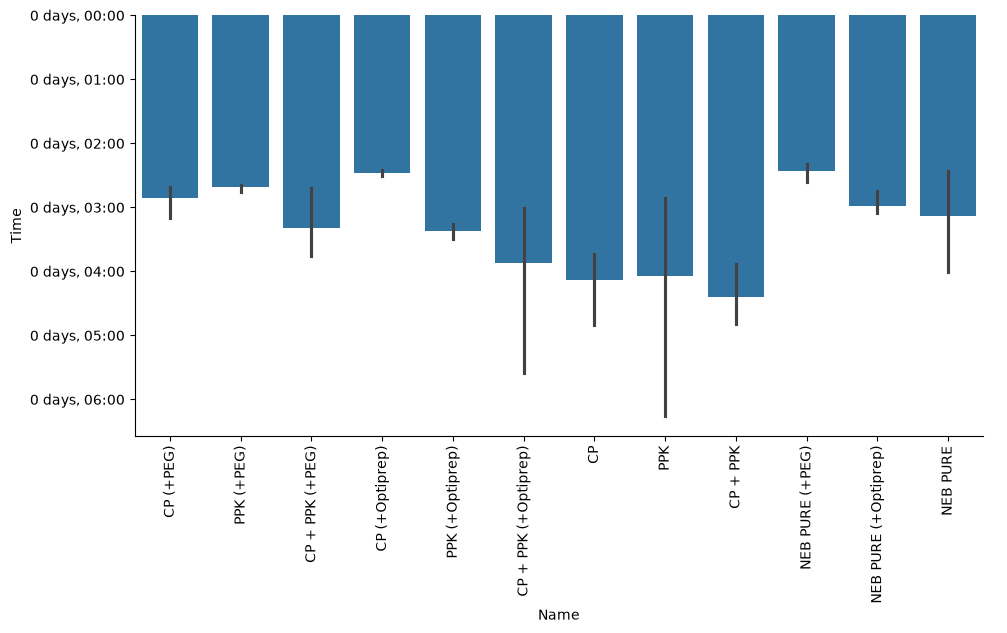

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(data=kinetics["Steady State"], y="Time", x="Name", kind="bar", orient="v", aspect=2)

# The names are still kind of long, so we need to rotate them in order to read them properly.
g.set_xticklabels(rotation=90)

Quick experiment to see if there is some spatial effect to the variance on the plate. It doesn't particularly look like it, though I could belive that it's getting kind of worse as we go down from row B, to C, to D.

<Axes: xlabel='Col', ylabel='Row'>

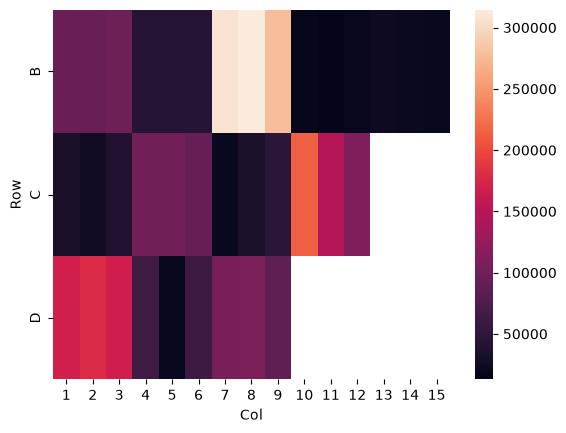

In [26]:
ss = pr.find_steady_state(data, group_by=["Well"]).reset_index()
ss["Row"] = ss["Well"].str[:1]
ss["Col"] = pd.to_numeric(ss["Well"].str[1:])
sns.heatmap(ss.pivot(index="Row", columns="Col", values="Data_steadystate"))

# Summary

Overall summary of experiment

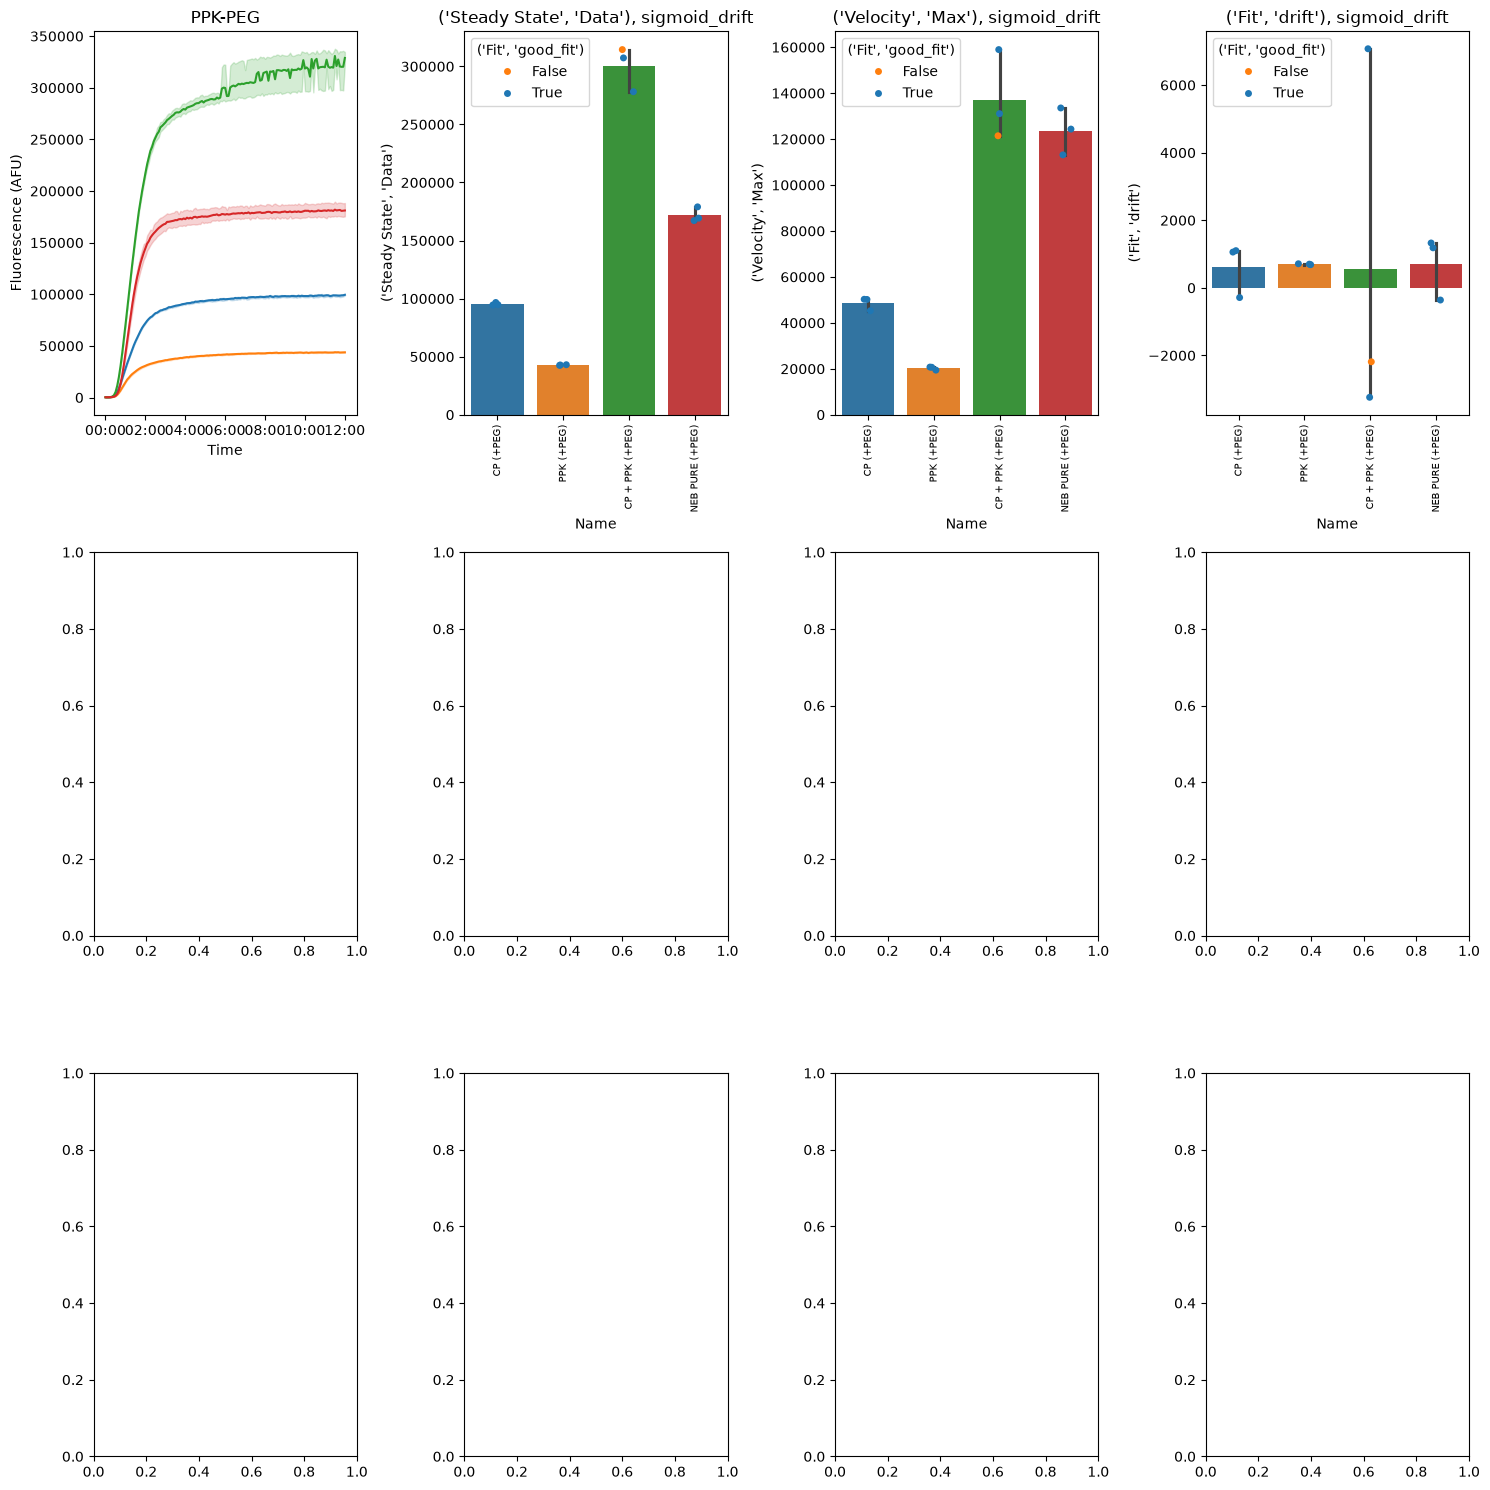

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [27]:
pr.plot_summary(data)

PROVIDING AVERAGED KINETICS


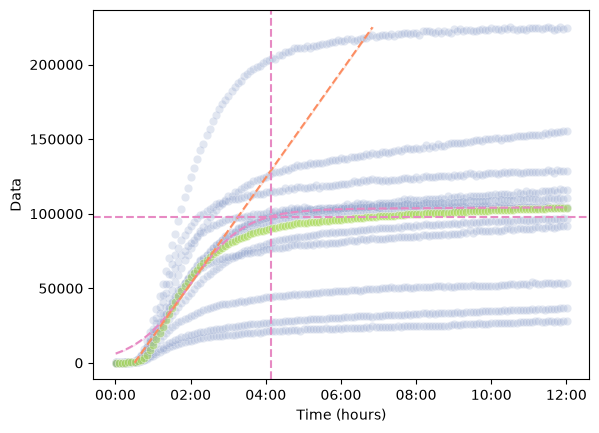

In [28]:
df = data[data["Experiment"] == "PPK"]
kinetics = pr.kinetic_analysis(df, ["Name"])
kinetics
pr.plot_kinetics_by_well(
    data=df,
    kinetics=kinetics,
    group_by=["Name"],
    show_mean=True,
    show_fit=True,
    annotate=False,
    hue="Name"
)

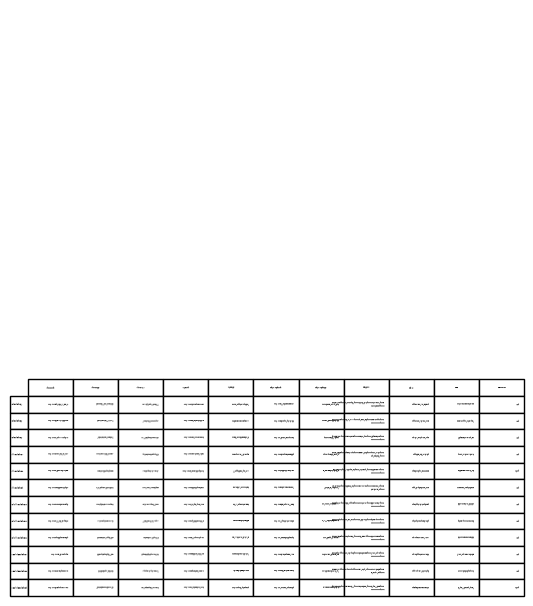

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots()
ax.axis('off')
pd.plotting.table(ax, pr.kinetic_analysis(df))